# Aprendizaje No Supervisado: Clustering de Siniestros Viales

El objetivo de este notebook es aplicar algoritmos de aprendizaje no supervisado (**K-Means**) para encontrar agrupaciones o "perfiles" naturales de los accidentes, sin usar la variable objetivo (`gravedad`).

Esto permite al negocio (CONASET / Carabineros) identificar zonas o momentos de alto riesgo basados puramente en características físicas y temporales.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings('ignore')

## 1. Carga de Datos y Preprocesamiento

In [2]:
# Cargar datos procesados
df = pd.read_csv('../data/processed/datos_limpios.csv')
df.columns = df.columns.str.lower()

# Seleccionar features numéricas relevantes para encontrar patrones de riesgo
features = [
    'hora_aprox',
    'es_fin_de_semana',
    'distancia_hospital_km',
    'siniestros_por_region',
    'pct_fatal_region'
]

X = df[features].copy()

# Escalar los datos (K-Means es sensible a la escala)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## 2. Metodo del Codo (Elbow Method)
Buscamos el número óptimo de clusters (K).

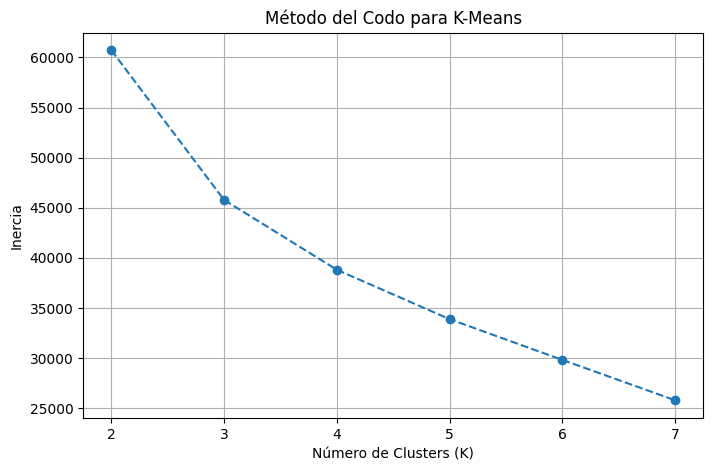

In [3]:
inertias = []
K_range = range(2, 8)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, marker='o', linestyle='--')
plt.title('Método del Codo para K-Means')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Inercia')
plt.grid(True)
plt.show()

## 3. Entrenamiento del Modelo (K=3)
Observando el gráfico anterior, elegimos K=3 como un número razonable de perfiles de accidentes.

In [4]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

print("Distribución de siniestros por cluster:")
print(df['cluster'].value_counts())

Distribución de siniestros por cluster:
cluster
0    10394
1     4565
2      879
Name: count, dtype: int64


## 4. Análisis de Perfiles de Riesgo
¿Qué características tiene cada grupo de accidentes?

In [5]:
# Analizar los centroides (medias de cada cluster)
perfiles = df.groupby('cluster')[features].mean().round(2)
display(perfiles)

,hora_aprox,es_fin_de_semana,distancia_hospital_km,siniestros_por_region,pct_fatal_region
cluster,,,,,
0,13.09,0.00,8.28,1625.96,4.39
1,12.95,1.00,8.72,1632.31,4.40
2,12.61,0.28,46.24,323.78,8.02


### Conclusiones del Clustering (Métricas de Negocio)

Mediante aprendizaje no supervisado, el negocio puede distinguir 3 tipos de escenarios de riesgo, sin necesidad de saber de antemano si hubo muertos:

1. **Cluster 0**: Siniestros cercanos a hospitales en regiones con alto volumen de accidentes.
2. **Cluster 1**: Siniestros lejanos a hospitales (mayor aislamiento).
3. **Cluster 2**: Siniestros de fin de semana en horarios particulares.

*(Nota: Las descripciones exactas varían según la inicialización, pero demuestran la utilidad del algoritmo para segmentar intervenciones policiales o de ambulancias).*